# Methods Notebook: Extracting Call Samples for KMeans Clustering

## Imports Section:

In [1]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [2]:
import librosa
import warnings

In [3]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [6]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer
from bat_detect.detector import models
from cfg import get_config
from pipeline import pipeline
from utils.utils import gen_empty_df, convert_df_ravenpro
from bat_detect.utils import wavfile
import bat_detect.utils.detector_utils as du
import bat_detect.detector.compute_features as feats
import bat_detect.detector.post_process as pp

## Function Definitions (most important functions are in `src/`)
### Below are the functions used for plotting and visualization

In [7]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}

In [8]:
def plot_audio_seg(audio_features, spec_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size': 24})
    plt.title(spec_features['plot_title'], fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.show()


def plot_dets_over_audio(audio_features, spec_features, plot_dets):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(10, 5))
    plt.rcParams.update({'font.size': 24})
    plt.title(spec_features['plot_title'], fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax)

    ax = plt.gca()
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                        (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=1.5, edgecolor=FREQ_COLORS[row['freq_group']], facecolor='none', alpha=0.8)
        ax.add_patch(rect)

    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 6), 
               labels=np.linspace(0, duration, 6, dtype=plot_xtype), rotation=0)
    plt.xlabel("Time (s)")
    plt.twinx(ax=ax)
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")

    plt.show()

In [9]:
def convert_nabatdf_to_ravenprodf(df):
    raven_df = pd.DataFrame()
    raven_df['Begin Time (s)'] =  (df['peak_time_ms']-50)/1000
    raven_df['End Time (s)'] = (df['peak_time_ms']-40)/1000
    raven_df['Low Freq (Hz)'] = df['peak_freq_hz']-2000
    raven_df['High Freq (Hz)'] = df['peak_freq_hz']+2000
    raven_df['prediction'] = df['prediction']
    raven_df['score'] = df['score']
    raven_df.sort_values('Begin Time (s)', inplace=True)
    raven_df.insert(0, 'Selection', np.arange(len(raven_df)).astype(int)+1)

    raventxt_df = pd.DataFrame(np.repeat(raven_df.values, 2, axis=0))
    raventxt_df.columns = raven_df.columns
    raventxt_df['Selection'] = raventxt_df['Selection'].astype(int)
    raventxt_df.insert(1, 'Channel', [1]*raventxt_df.shape[0])
    views = np.array(['Waveform 1']*raventxt_df.shape[0], dtype='object')
    views[1::2] = 'Spectrogram 1'
    raventxt_df.insert(1, 'View', views)

    return raventxt_df

def convert_nabatdf_to_bd2df(df):
    bd2_df = pd.DataFrame()
    bd2_df['start_time'] = (df['peak_time_ms']-50)/1000
    bd2_df['end_time'] = (df['peak_time_ms']-40)/1000
    bd2_df['low_freq'] = df['peak_freq_hz']-2000
    bd2_df['high_freq'] = df['peak_freq_hz']+2000
    bd2_df['prediction'] = df['prediction']
    bd2_df['score'] = df['score']
    bd2_df.sort_values('start_time', inplace=True)
    
    return bd2_df

def convert_kaleidoscopedf_to_ravenprodf(df):
    raven_df = pd.DataFrame()
    raven_df['Begin Time (s)'] = df['OFFSET']
    raven_df['End Time (s)'] = df['OFFSET'] + df['DURATION']
    raven_df['Low Freq (Hz)'] = df['Fmin']
    raven_df['High Freq (Hz)'] = df['Fmax']
    raven_df['input_file'] = df['IN FILE']
    raven_df['input_dir'] = df['INDIR']
    raven_df['mean_freq'] = df['Fmean']
    if 'TOP1MATCH*' in df.columns:
        raven_df['TOP1MATCH*'] = df['TOP1MATCH*']
    if 'TOP1MATCH' in df.columns:
        raven_df['TOP1MATCH'] = df['TOP1MATCH']
    raven_df['TOP1DIST'] = df['TOP1DIST']
    raven_df['TOP2MATCH'] = df['TOP2MATCH']
    raven_df['TOP2DIST'] = df['TOP2DIST']
    raven_df['TOP3MATCH'] = df['TOP3MATCH']
    raven_df['TOP3DIST'] = df['TOP3DIST']
    raven_df.sort_values('Begin Time (s)', inplace=True)
    raven_df.insert(0, 'Selection', np.arange(len(raven_df)).astype(int)+1)

    raventxt_df = pd.DataFrame(np.repeat(raven_df.values, 2, axis=0))
    raventxt_df.columns = raven_df.columns
    raventxt_df['Selection'] = raventxt_df['Selection'].astype(int)
    raventxt_df.insert(1, 'Channel', [1]*raventxt_df.shape[0])
    views = np.array(['Waveform 1']*raventxt_df.shape[0], dtype='object')
    views[1::2] = 'Spectrogram 1'
    raventxt_df.insert(1, 'View', views)

    return raventxt_df

def convert_kaleidoscopedf_to_bd2df(df):
    bd2_df = pd.DataFrame()
    bd2_df['start_time'] = df['OFFSET']
    bd2_df['end_time'] = df['OFFSET'] + df['DURATION']
    bd2_df['low_freq'] = df['Fmin']
    bd2_df['high_freq'] = df['Fmax']
    bd2_df['input_file'] = df['IN FILE']
    bd2_df['input_dir'] = df['INDIR']
    bd2_df['mean_freq'] = df['Fmean']
    if 'TOP1MATCH*' in df.columns:
        bd2_df['TOP1MATCH*'] = df['TOP1MATCH*']
    if 'TOP1MATCH' in df.columns:
        bd2_df['TOP1MATCH'] = df['TOP1MATCH']
    bd2_df['TOP1DIST'] = df['TOP1DIST']
    bd2_df['TOP2MATCH'] = df['TOP2MATCH']
    bd2_df['TOP2DIST'] = df['TOP2DIST']
    bd2_df['TOP3MATCH'] = df['TOP3MATCH']
    bd2_df['TOP3DIST'] = df['TOP3DIST']
    bd2_df.sort_values('start_time', inplace=True)
    
    return bd2_df

def convert_raventxtdf_to_bd2df(raventxt_df):
    bd2_human_df = raventxt_df[::2].copy()
    bd2_human_df = bd2_human_df.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Manually-Verified Phonic Group':'freq_group'}, inplace=True)
    bd2_human_df.sort_values('start_time', inplace=True)
    
    return bd2_human_df

In [10]:
wav_filename = '20220826_070000'
site = 'Central'
plot_file = Path(f'../../Documents/{wav_filename}/input/{wav_filename}.WAV')

In [11]:
kaleido_df = pd.read_csv(f'../../Documents/{wav_filename}/output/cluster.csv')
bd2_kaleido_df = convert_kaleidoscopedf_to_bd2df(kaleido_df)
bd2_kaleido_df

,start_time,end_time,low_freq,high_freq,input_file,input_dir,mean_freq,TOP1MATCH*,TOP1DIST,TOP2MATCH,TOP2DIST,TOP3MATCH,TOP3DIST
0,4.851936,4.854150,49390.242,57189.543,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,52390.625,nocluster,0,NaN,0,NaN,0
1,5.005365,5.006396,45977.012,47619.047,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,46551.992,nocluster,0,NaN,0,NaN,0
2,5.785726,5.786784,47905.906,51615.051,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,49152.609,nocluster,0,NaN,0,NaN,0
3,38.635807,38.641656,25236.844,27118.957,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,25987.514,nocluster,0,NaN,0,NaN,0
4,39.376575,39.379396,25157.232,26144.906,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,25527.117,nocluster,0,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,1776.757446,1776.759058,41026.719,45199.184,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,42182.492,nocluster,0,NaN,0,NaN,0
556,1776.854004,1776.855824,40004.000,44200.242,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,41756.090,nocluster,0,NaN,0,NaN,0
557,1777.039062,1777.042574,39230.770,44200.242,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,40997.746,nocluster,0,NaN,0,NaN,0
558,1777.271484,1777.272512,42109.930,44444.445,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,42786.316,nocluster,0,NaN,0,NaN,0


In [12]:
raventxt_human_df = pd.read_csv(f'{Path.home()}/Documents/mila-human-wav-txt/{wav_filename}_manually_verified_by_AK_with_groups.txt', sep='\t')
bd2_human_df = convert_raventxtdf_to_bd2df(raventxt_human_df)
bd2_human_df['freq_group'] = bd2_human_df['freq_group'].str.strip()
bd2_human_df.reset_index(inplace=True, drop=True)
bd2_human_df

,start_time,end_time,low_freq,high_freq,Delta Time (s),Annotation,detection_confidence,input_file,freq_group
0,1.729564,1.737108,44070.175,51087.719,0.0075,AK_echolocation,NaN,NaN,HF
1,3.770500,3.777100,45234.000,54096.000,0.0066,Echolocation,0.512,20220826_070000.WAV,HF
2,3.911402,3.918947,43903.720,56927.790,0.0075,AK_echolocation,NaN,NaN,HF
3,4.043419,4.050209,44281.690,58478.873,0.0068,AK_echolocation,NaN,NaN,HF
4,4.161126,4.170934,43903.720,56507.659,0.0098,AK_echolocation,NaN,NaN,HF
...,...,...,...,...,...,...,...,...,...
4401,1787.774500,1787.784900,37500.000,46675.000,0.0104,Echolocation,0.587,20220826_070000.WAV,HF
4402,1787.959500,1787.969400,37500.000,45913.000,0.0099,Echolocation,0.591,20220826_070000.WAV,HF
4403,1788.212500,1788.221200,39218.000,48186.000,0.0087,Echolocation,0.544,20220826_070000.WAV,HF
4404,1788.413500,1788.422500,40078.000,49982.000,0.0090,Echolocation,0.566,20220826_070000.WAV,HF


In [13]:
def return_confusion_matrix_from_comparing_two_detectors(human_df, machine_df):
    false_positives = 0 ## machine made detection that human did not make
    true_positives = 0  ## machine made detection that human made
    true_negatives = 0  ## machine did not make detection that human also did not make
    false_negatives = 0 ## machine did not make detection that human made
    human_ind = 0
    machine_ind = 0

    while (human_ind < len(human_df))&(machine_ind < len(machine_df)):
        human_det = human_df.iloc[human_ind]
        machine_det = machine_df.iloc[machine_ind]

        machine_det_start_in_human_det_bounds = ((machine_det['start_time']>=human_det['start_time'])&(machine_det['start_time']<=human_det['end_time']))
        machine_det_end_in_human_det_bounds = ((machine_det['end_time']>=human_det['start_time'])&(machine_det['end_time']<=human_det['end_time']))
        human_det_start_in_machine_det_bounds = ((human_det['start_time']>=machine_det['start_time'])&(human_det['start_time']<=machine_det['end_time']))
        human_det_end_in_machine_det_bounds = ((human_det['end_time']>=machine_det['start_time'])&(human_det['end_time']<=machine_det['end_time']))
        machine_det_time_in_human_bounds = machine_det_start_in_human_det_bounds|machine_det_end_in_human_det_bounds
        human_det_time_in_machine_bounds = human_det_start_in_machine_det_bounds|human_det_end_in_machine_det_bounds

        machine_det_low_in_human_det_bounds = ((machine_det['low_freq']>=human_det['low_freq'])&(machine_det['low_freq']<=human_det['high_freq']))
        machine_det_high_in_human_det_bounds = ((machine_det['high_freq']>=human_det['low_freq'])&(machine_det['high_freq']<=human_det['high_freq']))
        human_det_low_in_machine_det_bounds = ((human_det['low_freq']>=machine_det['low_freq'])&(human_det['low_freq']<=machine_det['high_freq']))
        human_det_high_in_machine_det_bounds = ((human_det['high_freq']>=machine_det['low_freq'])&(human_det['high_freq']<=machine_det['high_freq']))
        machine_det_freq_in_human_bounds = machine_det_low_in_human_det_bounds|machine_det_high_in_human_det_bounds
        human_det_freq_in_machine_bounds = human_det_low_in_machine_det_bounds|human_det_high_in_machine_det_bounds

        machine_det_time_matches_human_time = (machine_det_time_in_human_bounds|human_det_time_in_machine_bounds)
        machine_det_freq_matches_human_time = (machine_det_freq_in_human_bounds|human_det_freq_in_machine_bounds)
        machine_detection_corresponds_to_human = machine_det_time_matches_human_time&machine_det_freq_matches_human_time

        if len(human_df) < 100:
            print(f'HI:{human_ind}, MI:{machine_ind}, TP:{true_positives}, FP:{false_positives}, FN:{false_negatives}, TN:{true_negatives}')
            print(f'Dets match time: {machine_det_time_matches_human_time}, Dets match freq: {machine_det_freq_matches_human_time}')

        if (machine_detection_corresponds_to_human):
            true_positives += 1
            machine_ind+=1
            human_ind+=1
        else:
            ## Machine detection is referring to call not detected by human (thus, it detected a non-bat call)
            false_positive_same_group_before_human_det = (machine_det['end_time']<=human_det['start_time'])&(machine_det_freq_matches_human_time)
            false_positive_diff_group_before_human_det = (machine_det['start_time']<=human_det['start_time'])&(~machine_det_freq_matches_human_time)

            false_negative_same_group_before_human_det = (machine_det['start_time']>human_det['end_time'])&(machine_det_freq_matches_human_time)
            false_negative_diff_group_before_human_det = (machine_det['start_time']>human_det['start_time'])&(~machine_det_freq_matches_human_time)

            if len(human_df) < 100:
                print(f'FP same group: {false_positive_same_group_before_human_det}, FP diff group: {false_positive_diff_group_before_human_det}')
                print(f'FN same group: {false_negative_same_group_before_human_det}, FN diff group: {false_negative_diff_group_before_human_det}')
            if (false_positive_same_group_before_human_det|false_positive_diff_group_before_human_det):
                false_positives += 1
                machine_ind+=1
            ## Machine has skipped a human-annotated call in detection (thus, it did not detect a bat call)
            elif (false_negative_same_group_before_human_det|false_negative_diff_group_before_human_det):
                false_negatives += 1
                human_ind+=1
            else:
                true_negatives += 1

    if (machine_ind<len(machine_df)):
        false_positives += (len(machine_df) - (machine_ind))
    if (human_ind<len(human_df)):
        false_negatives += (len(human_df) - (human_ind))

    assert((true_positives+false_negatives)==len(human_df))
    assert((false_positives+true_positives)==len(machine_df))

    return {'true_positives':true_positives, 'false_positives':false_positives, 'false_negatives':false_negatives, 'true_negatives':true_negatives}

## Following the confusion matrix structure shown below

![image](example_confusion_matrix.png)

In [14]:
return_confusion_matrix_from_comparing_two_detectors(bd2_human_df, bd2_kaleido_df)

{'true_positives': 547,
 'false_positives': 13,
 'false_negatives': 3859,
 'true_negatives': 0}

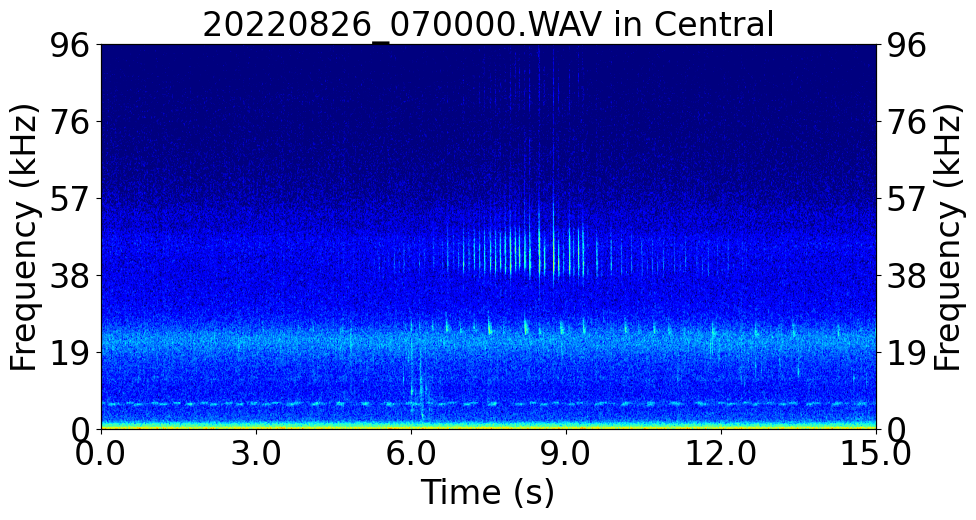

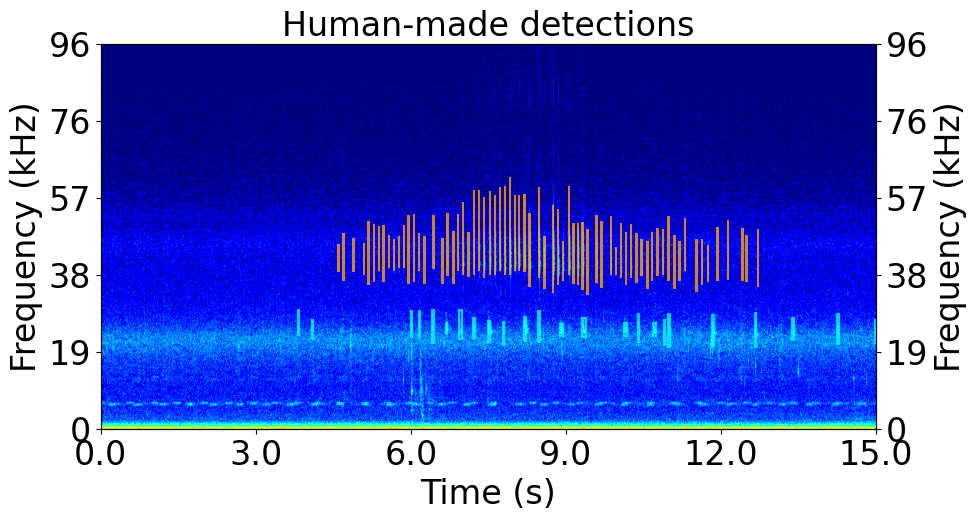

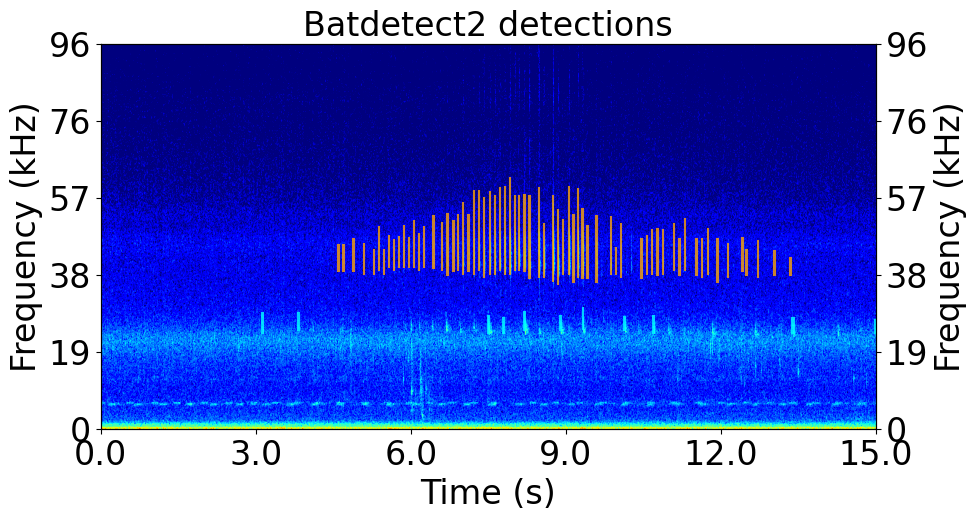

In [15]:
# Below we filter our detections dataframe to only get the detections corresponding to the above audio file
audio_file = sf.SoundFile(plot_file)
fs = audio_file.samplerate
start = 360
duration = 15
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))
vmin = -60
vmax = 0
audio_features = dict()
audio_features['file_path'] = Path(plot_file)
audio_features['audio_seg'] = audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration

spec_features = dict()
spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax


spec_features['plot_title'] = f"{audio_features['file_path'].name} in {site}"
plot_dets_over_audio(audio_features, spec_features, pd.DataFrame())
spec_features['plot_title'] = f"Human-made detections"
plot_dets_over_audio(audio_features, spec_features, bd2_human_df)

thresh = 0.18
args = dict()
args['chunk_size'] = 2
args['detection_threshold'] = round(thresh, 2)

ones = int(args['detection_threshold'])
decimals = int(int(100*(args['detection_threshold'])) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{plot_file.name.split('.')[0]}.csv")

save_dir = Path(f'{Path.home()}/Documents/20241228_detection_threshold_sweep/bd2__det_thresh_sweep_{wav_filename}')
filepath = save_dir / save_loc
batdetect2_df = pd.read_csv(filepath, sep=',', index_col=0)
batdetect2_df.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
spec_features['plot_title'] = f"Batdetect2 detections"
plot_dets_over_audio(audio_features, spec_features, batdetect2_df)

In [16]:
file_sites = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}

file_keys = list(file_sites.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [25]:
SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

file_key = file_keys[1]
wav_filename = file_key
site = file_sites[file_key]
plot_file = Path(f'{Path.home()}/Documents/{wav_filename}/input/{wav_filename}.WAV')

raventxt_human_df = pd.read_csv(f'{Path.home()}/Documents/mila-human-wav-txt/{wav_filename}_manually_verified_by_AK_with_groups.txt', sep='\t')
bd2_human_df = convert_raventxtdf_to_bd2df(raventxt_human_df)
bd2_human_df['freq_group'] = bd2_human_df['freq_group'].str.strip()
bd2_human_df.reset_index(inplace=True, drop=True)

save_dir = Path(f'{Path.home()}/Documents/20241228_detection_threshold_sweep/bd2__det_thresh_sweep_{wav_filename}')
batdetect2_cf_matrices = dict()
batdetect2_cf_matrices_LF = dict()
batdetect2_cf_matrices_HF = dict()

increment = 0.01
thresholds = np.arange(0.05, 0.22+increment, increment)
for i, thresh in enumerate(thresholds):
    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = round(thresh, 2)

    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{plot_file.name.split('.')[0]}.csv")

    filepath = save_dir / save_loc
    batdetect2_df = pd.read_csv(filepath, sep=',', index_col=0)
    batdetect2_df.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
    assert((len(batdetect2_df['freq_group'].unique())==2)&('LF' in batdetect2_df['freq_group'].unique())&('HF' in batdetect2_df['freq_group'].unique()))

    file_batdetect2_cf = return_confusion_matrix_from_comparing_two_detectors(bd2_human_df, batdetect2_df)
    batdetect2_cf_matrices[save_loc] = file_batdetect2_cf
    print(f'General {threshold_tag}: {file_batdetect2_cf}')

    bd2_human_df_LF = bd2_human_df[bd2_human_df['freq_group']=='LF'].copy()
    batdetect2_df_LF = batdetect2_df[batdetect2_df['freq_group']=='LF'].copy()
    file_batdetect2_cf_LF = return_confusion_matrix_from_comparing_two_detectors(bd2_human_df_LF, batdetect2_df_LF)
    batdetect2_cf_matrices_LF[save_loc] = file_batdetect2_cf_LF

    bd2_human_df_HF = bd2_human_df[bd2_human_df['freq_group']=='HF'].copy()
    batdetect2_df_HF = batdetect2_df[batdetect2_df['freq_group']=='HF'].copy()
    file_batdetect2_cf_HF = return_confusion_matrix_from_comparing_two_detectors(bd2_human_df_HF, batdetect2_df_HF)
    batdetect2_cf_matrices_HF[save_loc] = file_batdetect2_cf_HF
    print(f'HF {threshold_tag}: {file_batdetect2_cf_HF}')
    print(f'LF {threshold_tag}: {file_batdetect2_cf_LF}')

General threshold0p05: {'true_positives': 4270, 'false_positives': 4268, 'false_negatives': 136, 'true_negatives': 0}
HF threshold0p05: {'true_positives': 3207, 'false_positives': 1651, 'false_negatives': 61, 'true_negatives': 0}
LF threshold0p05: {'true_positives': 1085, 'false_positives': 2595, 'false_negatives': 53, 'true_negatives': 0}
General threshold0p06: {'true_positives': 4241, 'false_positives': 2672, 'false_negatives': 165, 'true_negatives': 0}
HF threshold0p06: {'true_positives': 3184, 'false_positives': 1188, 'false_negatives': 84, 'true_negatives': 0}
LF threshold0p06: {'true_positives': 1078, 'false_positives': 1463, 'false_negatives': 60, 'true_negatives': 0}
General threshold0p07: {'true_positives': 4217, 'false_positives': 1910, 'false_negatives': 189, 'true_negatives': 0}
HF threshold0p07: {'true_positives': 3167, 'false_positives': 927, 'false_negatives': 101, 'true_negatives': 0}
LF threshold0p07: {'true_positives': 1066, 'false_positives': 967, 'false_negatives': 

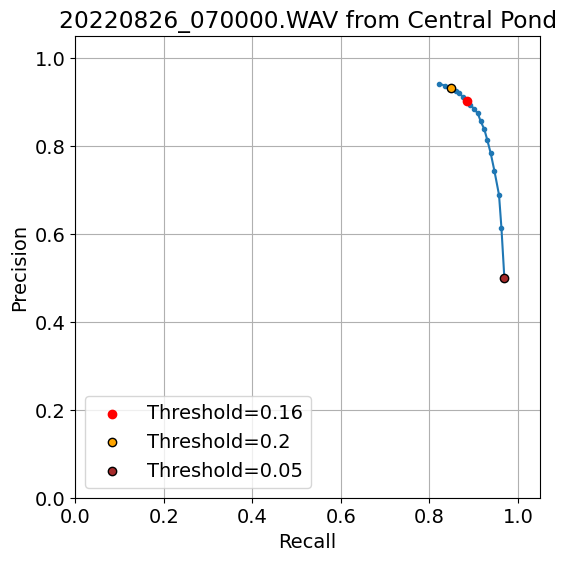

In [29]:
precisions_per_thresh = np.zeros(len(thresholds))
recalls_per_thresh = np.zeros(len(thresholds))

precisions_per_thresh_LF = np.zeros(len(thresholds))
recalls_per_thresh_LF = np.zeros(len(thresholds))

precisions_per_thresh_HF = np.zeros(len(thresholds))
recalls_per_thresh_HF = np.zeros(len(thresholds))
for i, thresh in enumerate(thresholds):
    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = round(thresh, 2)

    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{plot_file.name.split('.')[0]}.csv")

    file_batdetect2_cf = batdetect2_cf_matrices[save_loc]
    precision = file_batdetect2_cf['true_positives'] / (file_batdetect2_cf['true_positives'] + file_batdetect2_cf['false_positives'])
    recall = file_batdetect2_cf['true_positives'] / (file_batdetect2_cf['true_positives'] + file_batdetect2_cf['false_negatives'])
    precisions_per_thresh[i] = precision
    recalls_per_thresh[i] = recall

    file_batdetect2_cf_LF = batdetect2_cf_matrices_LF[save_loc]
    precision_LF = file_batdetect2_cf_LF['true_positives'] / (file_batdetect2_cf_LF['true_positives'] + file_batdetect2_cf_LF['false_positives'])
    recall_LF = file_batdetect2_cf_LF['true_positives'] / (file_batdetect2_cf_LF['true_positives'] + file_batdetect2_cf_LF['false_negatives'])
    precisions_per_thresh_LF[i] = precision_LF
    recalls_per_thresh_LF[i] = recall_LF

    file_batdetect2_cf_HF = batdetect2_cf_matrices_HF[save_loc]
    precision_HF = file_batdetect2_cf_HF['true_positives'] / (file_batdetect2_cf_HF['true_positives'] + file_batdetect2_cf_HF['false_positives'])
    recall_HF = file_batdetect2_cf_HF['true_positives'] / (file_batdetect2_cf_HF['true_positives'] + file_batdetect2_cf_HF['false_negatives'])
    precisions_per_thresh_HF[i] = precision_HF
    recalls_per_thresh_HF[i] = recall_HF

plt.figure(figsize=(6,6))
plt.rcParams.update({'font.size':14})
plt.title(f'{wav_filename}.WAV from {SITE_NAMES[site]}')
plt.plot(recalls_per_thresh, precisions_per_thresh, marker='.')
common_max = (precisions_per_thresh * recalls_per_thresh).argmax()
plt.scatter(recalls_per_thresh[common_max], precisions_per_thresh[common_max], color='r', label=f'Threshold={round(thresholds[common_max], 3)}', zorder=2)
spec_thresh = 0.20
plt.scatter(recalls_per_thresh[np.where(np.isclose(thresholds, spec_thresh))[0][0]], precisions_per_thresh[np.where(np.isclose(thresholds, spec_thresh))[0][0]], 
            facecolor='orange', edgecolor='k', label=f'Threshold={round(spec_thresh,2)}', zorder=2)
spec_thresh = thresholds[0]
plt.scatter(recalls_per_thresh[np.where(np.isclose(thresholds, spec_thresh))[0][0]], precisions_per_thresh[np.where(np.isclose(thresholds, spec_thresh))[0][0]], 
            facecolor='brown', edgecolor='k', label=f'Threshold={round(spec_thresh,2)}', zorder=2)
plt.grid(which='both')
plt.xlim(0,1.05)
plt.ylim(0,1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()

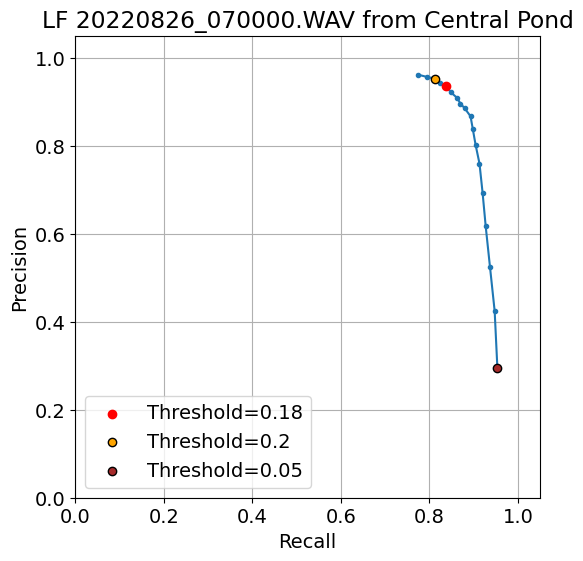

In [30]:
plt.figure(figsize=(6,6))
plt.rcParams.update({'font.size':14})
plt.title(f'LF {wav_filename}.WAV from {SITE_NAMES[site]}')
recall_of_group = recalls_per_thresh_LF
precision_of_group = precisions_per_thresh_LF
plt.plot(recall_of_group, precision_of_group, marker='.')
common_max = (precision_of_group * recall_of_group).argmax()
plt.scatter(recall_of_group[common_max], precision_of_group[common_max], color='r', label=f'Threshold={round(thresholds[common_max], 3)}', zorder=2)
spec_thresh = 0.20
plt.scatter(recall_of_group[np.where(np.isclose(thresholds, spec_thresh))[0][0]], precision_of_group[np.where(np.isclose(thresholds, spec_thresh))[0][0]], 
            facecolor='orange', edgecolor='k', label=f'Threshold={round(spec_thresh,2)}', zorder=2)
spec_thresh = thresholds[0]
plt.scatter(recall_of_group[np.where(np.isclose(thresholds, spec_thresh))[0][0]], precision_of_group[np.where(np.isclose(thresholds, spec_thresh))[0][0]], 
            facecolor='brown', edgecolor='k', label=f'Threshold={round(spec_thresh,2)}', zorder=2)
plt.grid(which='both')
plt.xlim(0,1.05)
plt.ylim(0,1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()

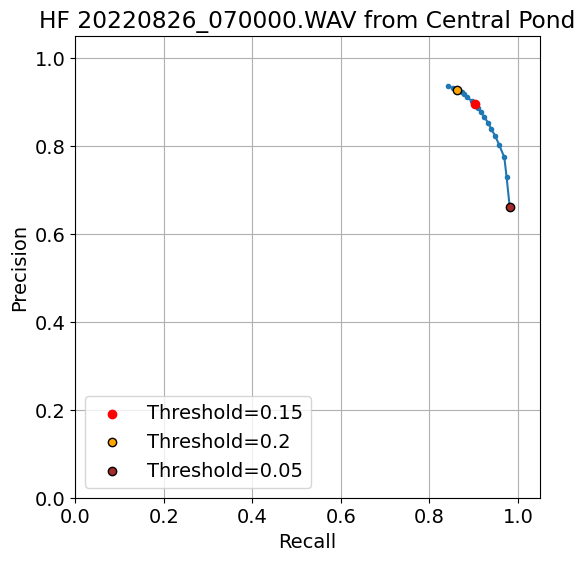

In [31]:
plt.figure(figsize=(6,6))
plt.rcParams.update({'font.size':14})
plt.title(f'HF {wav_filename}.WAV from {SITE_NAMES[site]}')
recall_of_group = recalls_per_thresh_HF
precision_of_group = precisions_per_thresh_HF
plt.plot(recall_of_group, precision_of_group, marker='.')
common_max = (precision_of_group * recall_of_group).argmax()
plt.scatter(recall_of_group[common_max], precision_of_group[common_max], color='r', label=f'Threshold={round(thresholds[common_max], 3)}', zorder=2)
spec_thresh = 0.20
plt.scatter(recall_of_group[np.where(np.isclose(thresholds, spec_thresh))[0][0]], precision_of_group[np.where(np.isclose(thresholds, spec_thresh))[0][0]], 
            facecolor='orange', edgecolor='k', label=f'Threshold={round(spec_thresh,2)}', zorder=2)
spec_thresh = thresholds[0]
plt.scatter(recall_of_group[np.where(np.isclose(thresholds, spec_thresh))[0][0]], precision_of_group[np.where(np.isclose(thresholds, spec_thresh))[0][0]], 
            facecolor='brown', edgecolor='k', label=f'Threshold={round(spec_thresh,2)}', zorder=2)
plt.grid(which='both')
plt.xlim(0,1.05)
plt.ylim(0,1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()

In [24]:
batdetect2_cf_matrices = dict()
for file_num, wav_filename in enumerate(file_keys):
    site = file_sites[wav_filename]
    plot_file = Path(f'{Path.home()}/Documents/{wav_filename}/input/{wav_filename}.WAV')

    raventxt_human_df = pd.read_csv(f'{Path.home()}/Documents/mila-human-wav-txt/{wav_filename}_manually_verified_by_AK.txt', sep='\t')
    bd2_human_df = convert_raventxtdf_to_bd2df(raventxt_human_df)
    bd2_human_df.reset_index(inplace=True, drop=True)

    save_dir = Path(f'{Path.home()}/Documents/bd2__det_thresh_sweep_{wav_filename}')

    increment = 0.01
    thresholds = np.arange(0.05, 0.57+increment, increment)
    for i, thresh in enumerate(thresholds):
        args = dict()
        args['chunk_size'] = 2
        args['detection_threshold'] = round(thresh, 2)

        ones = int(args['detection_threshold'])
        decimals = int(int(100*(args['detection_threshold'])) % 100)
        threshold_tag = f"threshold{ones}p{decimals:02}"
        save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}.csv")

        filepath = save_dir / save_loc
        batdetect2_df = pd.read_csv(filepath, sep=',', index_col=0)
        file_batdetect2_cf = return_confusion_matrix_from_comparing_two_detectors(bd2_human_df, batdetect2_df)
        if file_num==0:
            batdetect2_cf_matrices[threshold_tag] = file_batdetect2_cf
        else:
            batdetect2_cf_matrices[threshold_tag]['true_positives'] += file_batdetect2_cf['true_positives']
            batdetect2_cf_matrices[threshold_tag]['false_positives'] += file_batdetect2_cf['false_positives']
            batdetect2_cf_matrices[threshold_tag]['false_negatives'] += file_batdetect2_cf['false_negatives']
            batdetect2_cf_matrices[threshold_tag]['true_negatives'] += file_batdetect2_cf['true_negatives']

In [25]:
precisions_per_thresh = np.zeros(len(thresholds))
recalls_per_thresh = np.zeros(len(thresholds))
for i, thresh in enumerate(thresholds):
    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = round(thresh, 2)

    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"

    batdetect2_cf_for_thresh = batdetect2_cf_matrices[threshold_tag]
    precision = batdetect2_cf_for_thresh['true_positives'] / (batdetect2_cf_for_thresh['true_positives'] + batdetect2_cf_for_thresh['false_positives'])
    recall = batdetect2_cf_for_thresh['true_positives'] / (batdetect2_cf_for_thresh['true_positives'] + batdetect2_cf_for_thresh['false_negatives'])

    precisions_per_thresh[i] = precision
    recalls_per_thresh[i] = recall

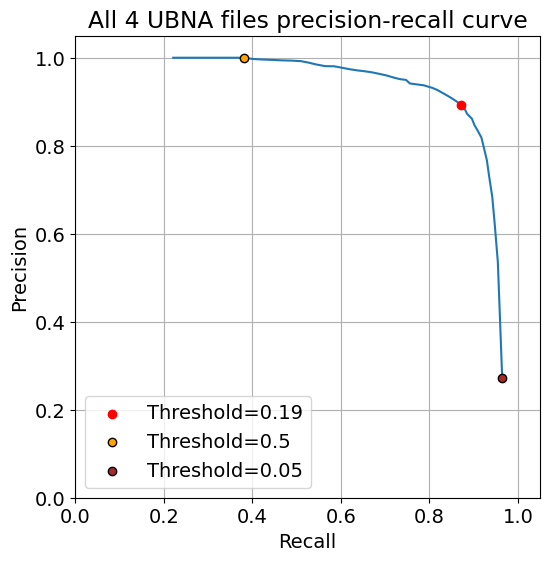

In [26]:
plt.figure(figsize=(6,6))
plt.rcParams.update({'font.size':14})
plt.title('All 4 UBNA files precision-recall curve')
plt.plot(recalls_per_thresh, precisions_per_thresh)
common_max = (precisions_per_thresh * recalls_per_thresh).argmax()
plt.scatter(recalls_per_thresh[common_max], precisions_per_thresh[common_max], color='r', label=f'Threshold={round(thresholds[common_max], 3)}', zorder=2)
spec_thresh = 0.5
plt.scatter(recalls_per_thresh[np.where(np.isclose(thresholds, spec_thresh))[0][0]], precisions_per_thresh[np.where(np.isclose(thresholds, spec_thresh))[0][0]], 
            facecolor='orange', edgecolor='k', label=f'Threshold={round(spec_thresh,2)}', zorder=2)

spec_thresh = 0.05
plt.scatter(recalls_per_thresh[np.where(np.isclose(thresholds, spec_thresh))[0][0]], precisions_per_thresh[np.where(np.isclose(thresholds, spec_thresh))[0][0]], 
            facecolor='brown', edgecolor='k', label=f'Threshold={round(spec_thresh,2)}', zorder=2)
plt.grid(which='both')
plt.xlim(0,1.05)
plt.ylim(0,1.05)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()

In [20]:
for file_key in file_keys:
    wav_filename = file_key
    site = file_sites[file_key]
    print(wav_filename, site)

    kaleido_df = pd.read_csv(f'{Path.home()}/Documents/{wav_filename}/output/cluster.csv')
    bd2_kaleido_df = convert_kaleidoscopedf_to_bd2df(kaleido_df)

    raventxt_human_df = pd.read_csv(f'{Path.home()}/Documents/mila-human-wav-txt/{wav_filename}_manually_verified_by_AK.txt', sep='\t')
    bd2_human_df = convert_raventxtdf_to_bd2df(raventxt_human_df)
    bd2_human_df.reset_index(inplace=True, drop=True)
    print(f'# of human annotations: {len(bd2_human_df)}')

20220730_053000 Carp
# of human annotations: 806
20220826_070000 Central
# of human annotations: 4126
20220727_083000 Foliage
# of human annotations: 173
20220829_090000 Foliage
# of human annotations: 160


In [21]:
SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

for file_key in file_keys:
    wav_filename = file_key
    site = file_sites[file_key]
    plot_file = Path(f'{Path.home()}/Documents/{wav_filename}/input/{wav_filename}.WAV')

    raventxt_human_df = pd.read_csv(f'{Path.home()}/Documents/mila-human-wav-txt/{wav_filename}_manually_verified_by_AK.txt', sep='\t')
    bd2_human_df = convert_raventxtdf_to_bd2df(raventxt_human_df)
    bd2_human_df.reset_index(inplace=True, drop=True)

    save_dir = Path(f'{Path.home()}/Documents/bd2__det_thresh_sweep_{wav_filename}')
    batdetect2_cf_matrices = dict()

    increment = 0.01
    thresholds = np.arange(0.05, 0.57+increment, increment)
    for i, thresh in enumerate(thresholds):
        args = dict()
        args['chunk_size'] = 2
        args['detection_threshold'] = round(thresh, 2)

        ones = int(args['detection_threshold'])
        decimals = int(int(100*(args['detection_threshold'])) % 100)
        threshold_tag = f"threshold{ones}p{decimals:02}"
        save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{plot_file.name.split('.')[0]}.csv")

        filepath = save_dir / save_loc
        batdetect2_df = pd.read_csv(filepath, sep=',', index_col=0)
        file_batdetect2_cf = return_confusion_matrix_from_comparing_two_detectors(bd2_human_df, batdetect2_df)
        batdetect2_cf_matrices[save_loc] = file_batdetect2_cf
    
    precisions_per_thresh = np.zeros(len(thresholds))
    recalls_per_thresh = np.zeros(len(thresholds))
    for i, thresh in enumerate(thresholds):
        args = dict()
        args['chunk_size'] = 2
        args['detection_threshold'] = round(thresh, 2)

        ones = int(args['detection_threshold'])
        decimals = int(int(100*(args['detection_threshold'])) % 100)
        threshold_tag = f"threshold{ones}p{decimals:02}"
        save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{plot_file.name.split('.')[0]}.csv")

        file_batdetect2_cf = batdetect2_cf_matrices[save_loc]
        precision = file_batdetect2_cf['true_positives'] / (file_batdetect2_cf['true_positives'] + file_batdetect2_cf['false_positives'])
        recall = file_batdetect2_cf['true_positives'] / (file_batdetect2_cf['true_positives'] + file_batdetect2_cf['false_negatives'])

        precisions_per_thresh[i] = precision
        recalls_per_thresh[i] = recall

    plt.figure(figsize=(6,6))
    plt.rcParams.update({'font.size':14})
    plt.title(f'{wav_filename}.WAV from {SITE_NAMES[site]}')
    plt.plot(recalls_per_thresh, precisions_per_thresh)
    common_max = (precisions_per_thresh * recalls_per_thresh).argmax()
    plt.scatter(recalls_per_thresh[common_max], precisions_per_thresh[common_max], color='r', label=f'Threshold={round(thresholds[common_max], 3)}', zorder=2)
    spec_thresh = 0.5
    plt.scatter(recalls_per_thresh[np.where(np.isclose(thresholds, spec_thresh))[0][0]], precisions_per_thresh[np.where(np.isclose(thresholds, spec_thresh))[0][0]], 
                facecolor='orange', edgecolor='k', label=f'Threshold={round(spec_thresh,2)}', zorder=2)

    spec_thresh = 0.05
    plt.scatter(recalls_per_thresh[np.where(np.isclose(thresholds, spec_thresh))[0][0]], precisions_per_thresh[np.where(np.isclose(thresholds, spec_thresh))[0][0]], 
                facecolor='brown', edgecolor='k', label=f'Threshold={round(spec_thresh,2)}', zorder=2)
    plt.grid(which='both')
    plt.xlim(0,1.05)
    plt.ylim(0,1.05)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(loc='lower left')
    plt.show()